In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import classification_report

# ==========================================
# 1. Tải Dataset và Tokenizer
# ==========================================
print("Loading dataset and tokenizer...")
dataset = load_dataset("glue", "qnli")
model_checkpoint = "t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# QNLI có 2 nhãn: entailment (0) và not_entailment (1)
# Hàm map để mã hóa câu hỏi và câu trả lời
def preprocess_function(examples):
    # Tokenizer sẽ tự động ghép 'question' và 'sentence' với format chuẩn của model
    return tokenizer(
        examples['question'], 
        examples['sentence'], 
        truncation=True, 
        max_length=256
    )

print("Tokenizing data...")
encoded_dataset = dataset.map(preprocess_function, batched=True)

# ==========================================
# 2. Khởi tạo Model
# ==========================================
# Mặc dù T5 là mô hình seq2seq, Hugging Face hỗ trợ SequenceClassification head
# tự động gắn lên trên encoder-decoder architecture.
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

# ==========================================
# 3. Cấu hình Metrics (Classification Report)
# ==========================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    # Xử lý output
    if isinstance(logits, tuple):
        logits = logits[0]
        
    predictions = np.argmax(logits, axis=-1)
    
    # Trả về dict chuẩn để Trainer ghi nhận (KHÔNG in ra màn hình ở đây nữa)
    report = classification_report(labels, predictions, output_dict=True, zero_division=0)
    return {
        "f1_macro": report["macro avg"]["f1-score"], 
        "accuracy": report["accuracy"]
    }

# ==========================================
# 4. Cấu hình Training
# ==========================================
batch_size = 4 # Chỉnh nhỏ lại (8 hoặc 4) nếu bị lỗi OOM (Out Of Memory) GPU

args = TrainingArguments(
    output_dir="./t5-qnli-checkpoints",
    eval_strategy="epoch",      # Đánh giá sau mỗi epoch
    save_strategy="epoch",      # Lưu model sau mỗi epoch
    logging_strategy="epoch",   # Log loss sau mỗi epoch để dễ vẽ đồ thị
    learning_rate=2e-5,         # T5 thường cần LR nhỏ
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,         # Fine-tune 3 epochs là chuẩn bài cho GLUE
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

# Sử dụng DataCollator để tự động padding các batch có độ dài không đồng đều
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"], # GLUE không có test set công khai nhãn, dùng validation
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ==========================================
# 5. Bắt đầu Train
# ==========================================
print("Bắt đầu huấn luyện...")
trainer.train()



Loading dataset and tokenizer...


README.md: 0.00B [00:00, ?B/s]

qnli/train-00000-of-00001.parquet:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

qnli/validation-00000-of-00001.parquet:   0%|          | 0.00/872k [00:00<?, ?B/s]

qnli/test-00000-of-00001.parquet:   0%|          | 0.00/877k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['transformer.encoder.embed_tokens.weight', 'transformer.decoder.embed_tokens.weight'].


TrainOutput(global_step=39279, training_loss=0.6500221671408386, metrics={'train_runtime': 15536.4418, 'train_samples_per_second': 20.225, 'train_steps_per_second': 2.528, 'total_flos': 3.259211305713396e+16, 'train_loss': 0.6500221671408386, 'epoch': 3.0})

In [2]:
# 5.5 IN CLASSIFICATION REPORT CỦA BEST MODEL
# ==========================================
print("\n" + "="*50)
print("ĐÁNH GIÁ BEST MODEL TRÊN TẬP VALIDATION")
print("="*50)

# Dùng trainer.predict để lấy logits và labels từ tập validation
val_predictions = trainer.predict(encoded_dataset["validation"])

# Trích xuất logits (val_predictions.predictions)
logits = val_predictions.predictions
if isinstance(logits, tuple):
    logits = logits[0]

# Chuyển logits thành nhãn dự đoán
best_preds = np.argmax(logits, axis=-1)
true_labels = val_predictions.label_ids

# In Classification Report duy nhất 1 lần
print(classification_report(
    true_labels, 
    best_preds, 
    target_names=["entailment", "not_entailment"], 
    digits=4
))


ĐÁNH GIÁ BEST MODEL TRÊN TẬP VALIDATION


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


                precision    recall  f1-score   support

    entailment     0.9146    0.9315    0.9230      2702
not_entailment     0.9318    0.9149    0.9232      2761

      accuracy                         0.9231      5463
     macro avg     0.9232    0.9232    0.9231      5463
  weighted avg     0.9233    0.9231    0.9231      5463



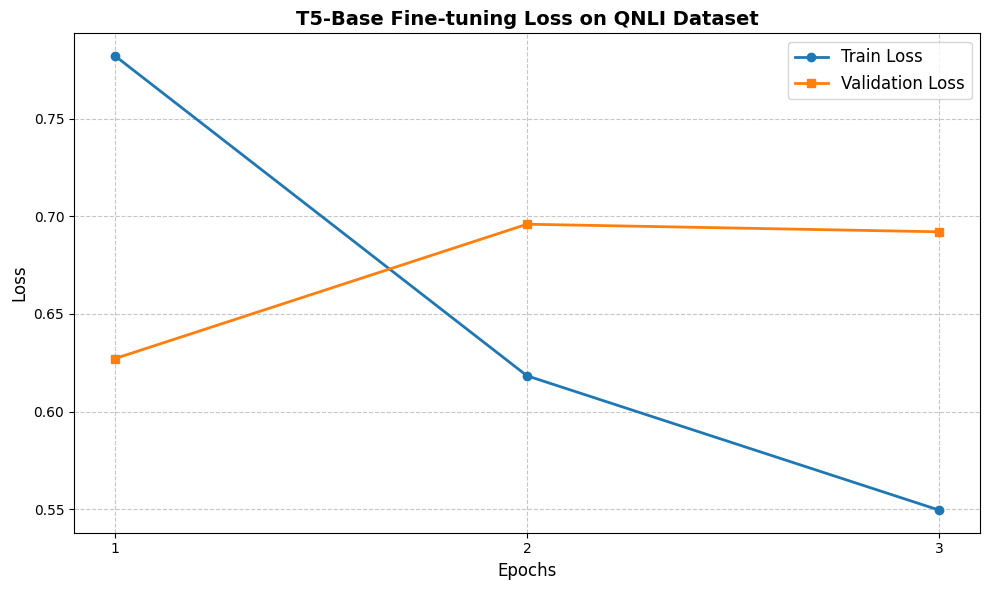

In [3]:
# ==========================================
# 6. Trích xuất Loss và Vẽ Đồ Thị
# ==========================================
# Lấy lịch sử logs từ state của trainer
log_history = trainer.state.log_history

epochs = []
train_loss = []
eval_loss = []

# Bóc tách dữ liệu từ file log
for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
        # Nếu log_history lưu rời rạc, ta cất epoch vào đây
        if log['epoch'] not in epochs:
            epochs.append(log['epoch'])
            
    elif 'eval_loss' in log and 'epoch' in log:
        eval_loss.append(log['eval_loss'])

# Đảm bảo độ dài mảng bằng nhau trước khi vẽ
min_len = min(len(train_loss), len(eval_loss), len(epochs))
epochs = epochs[:min_len]
train_loss = train_loss[:min_len]
eval_loss = eval_loss[:min_len]

# Vẽ đồ thị
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(epochs, train_loss, label='Train Loss', marker='o', linewidth=2, color='#1f77b4')
plt.plot(epochs, eval_loss, label='Validation Loss', marker='s', linewidth=2, color='#ff7f0e')

plt.title('T5-Base Fine-tuning Loss on QNLI Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()